# 03 - Análisis Exploratorio de Datos (EDA)

EDA sobre 22.617 asteroides (2021–2026) extraídos de NASA NeoWs.
El objetivo es entender las distribuciones, detectar problemas de
calidad y formular hipótesis sobre qué features van a ser relevantes
para la clasificación.

## 1. Carga de datos desde Supabase

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/asteroids_raw.csv')
print(f"Total: {df.shape[0]} filas, {df.shape[1]} columnas")

Total: 22617 filas, 9 columnas


## 2. Inspección inicial del dataset

In [2]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nEstadísticas descriptivas:")
print(df.describe())

Dimensiones: (22617, 9)

Tipos de datos:
id                            int64
name                         object
absolute_magnitude_h        float64
diameter_min_km             float64
diameter_max_km             float64
velocity_km_per_hour        float64
miss_distance_km            float64
close_approach_date          object
is_potentially_hazardous       bool
dtype: object

Valores nulos:
id                          0
name                        0
absolute_magnitude_h        0
diameter_min_km             0
diameter_max_km             0
velocity_km_per_hour        0
miss_distance_km            0
close_approach_date         0
is_potentially_hazardous    0
dtype: int64

Estadísticas descriptivas:
                 id  absolute_magnitude_h  diameter_min_km  diameter_max_km  \
count  2.261700e+04          22617.000000     22617.000000     22617.000000   
mean   3.963442e+07             24.477913         0.071942         0.160867   
std    2.307533e+07              2.553003         0.19594

## 3. Balance del target

In [3]:
conteo = df['is_potentially_hazardous'].value_counts()
porcentaje = df['is_potentially_hazardous'].value_counts(normalize=True) * 100

print("Conteo:")
print(conteo)
print("\nPorcentaje:")
print(porcentaje.round(2))

Conteo:
is_potentially_hazardous
False    21357
True      1260
Name: count, dtype: int64

Porcentaje:
is_potentially_hazardous
False    94.43
True      5.57
Name: proportion, dtype: float64



El dataset presenta desbalance de clases significativo: 94.43% no
peligrosos vs 5.57% peligrosos. En este contexto, accuracy no es una
métrica útil, un modelo que siempre prediga "no peligroso" tendría
94.43% de accuracy sin aprender nada. Se usará F1 Macro como métrica
principal y class_weight='balanced' en el entrenamiento.

## 4. Distribución de las features numéricas

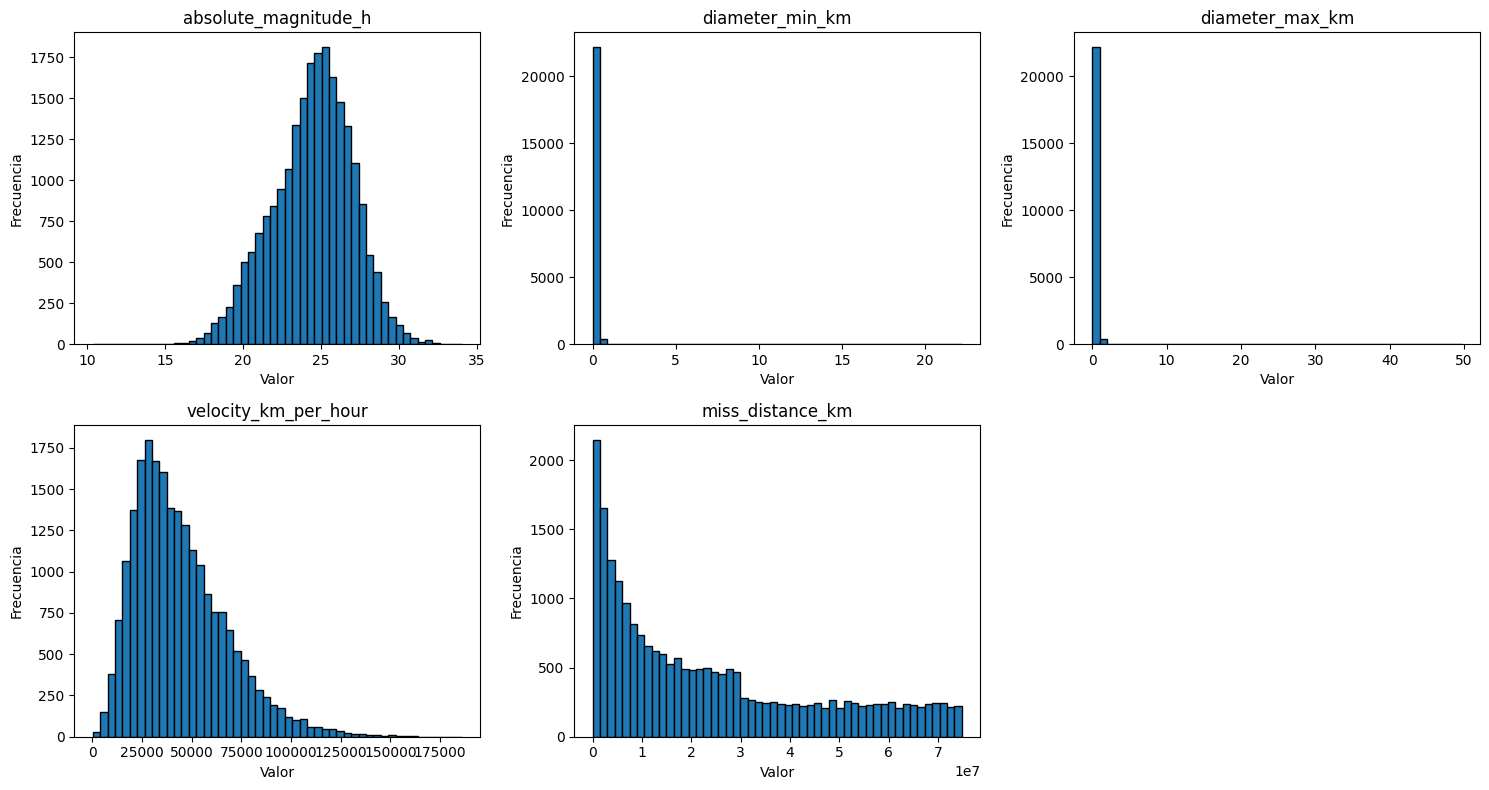

In [4]:
features = ['absolute_magnitude_h', 'diameter_min_km', 
            'diameter_max_km', 'velocity_km_per_hour', 'miss_distance_km']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=50, edgecolor='black')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

axes[5].axis('off')
plt.tight_layout()
plt.show()

Se identifican distribuciones asimétricas con colas largas hacia la
derecha en diameter, velocity y miss_distance. Estas distribuciones
requieren transformación logarítmica antes del modelado.
absolute_magnitude_h presenta distribución aproximadamente normal,
no requiere transformación.

## Separación por clase target

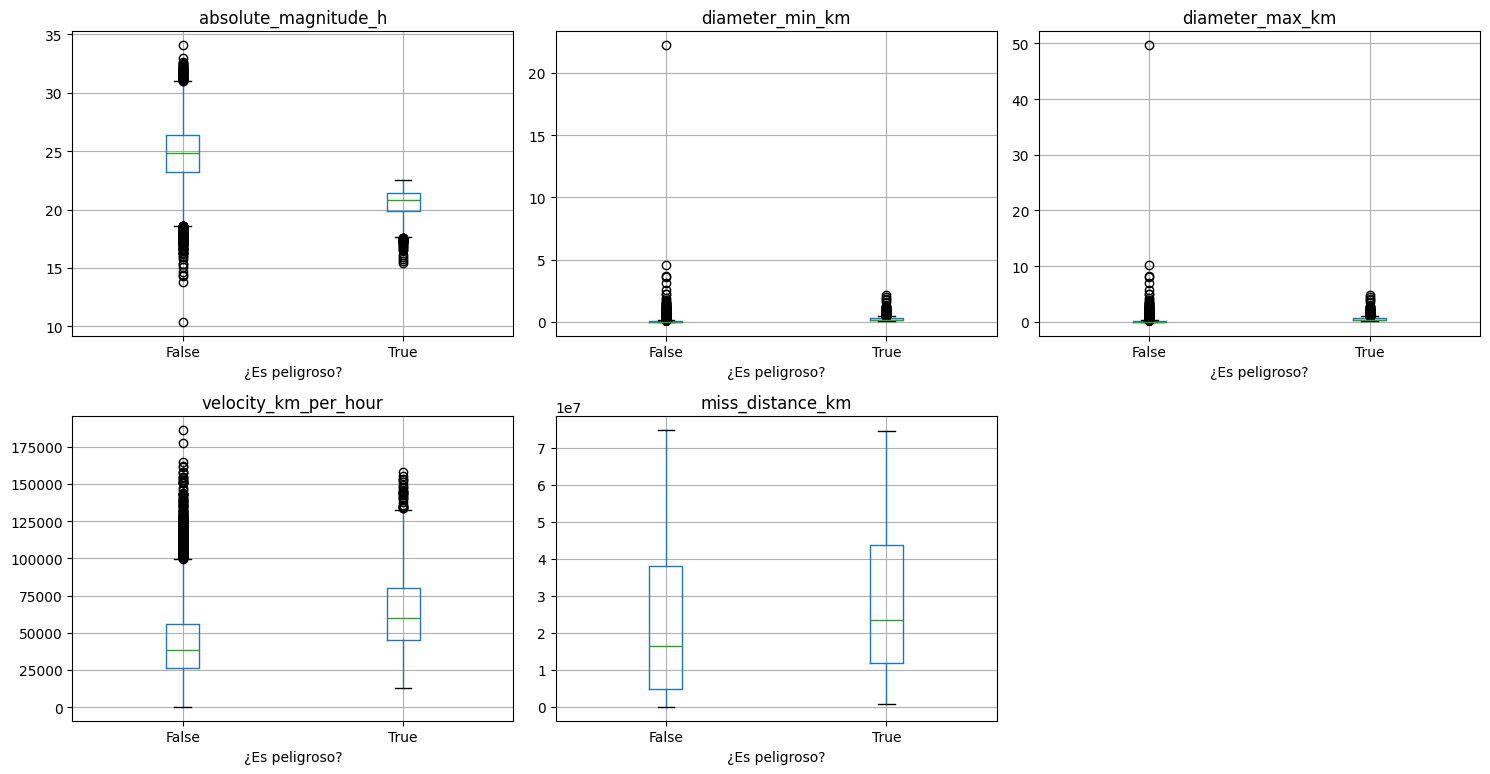

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    df.boxplot(column=feature, by='is_potentially_hazardous', ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('¿Es peligroso?')

axes[5].axis('off')
plt.suptitle('')
plt.tight_layout()
plt.show()

Los boxplots por clase revelan que absolute_magnitude_h es la feature
con mayor poder discriminativo. Los asteroides peligrosos tienen
magnitudes consistentemente más bajas (objetos más grandes).
miss_distance_km presenta distribuciones solapadas entre clases,
lo que anticipa un bajo poder predictivo de esta variable.

## 7. Matriz de correlación

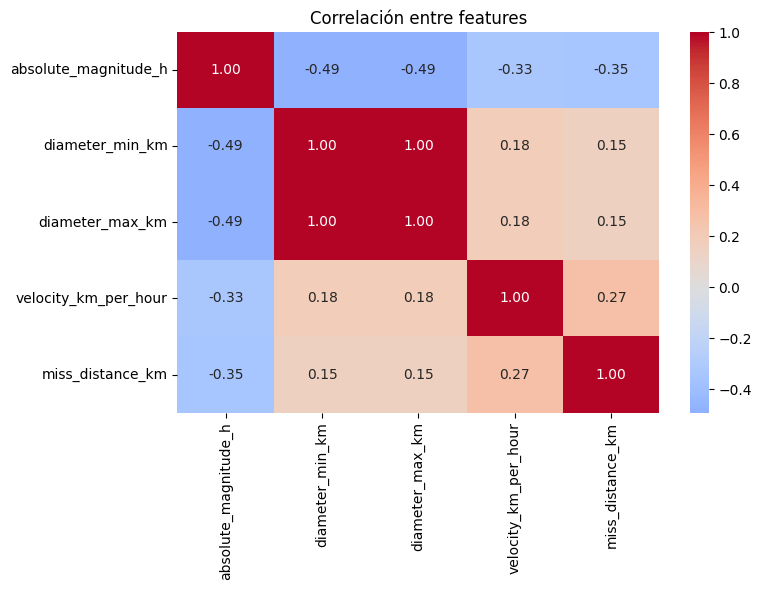

In [6]:
corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlación entre features')
plt.tight_layout()
plt.show()

diameter_min_km y diameter_max_km presentan correlación 1.00, 
son variables redundantes. Se combinarán en diameter_mean_km en el
preprocesamiento. El resto de correlaciones no supera 0.49, descartando
multicolinealidad problemática entre las demás features.

## Conclusiones del EDA

- Desbalance 94.4/5.6 → class_weight='balanced', métrica F1 Macro
- Features más discriminativas: absolute_magnitude_h, velocity_km_per_hour
- miss_distance_km tiene bajo poder predictivo, distribuciones solapadas
- Transformación logarítmica requerida en diameter, velocity, miss_distance
- diameter_min_km y diameter_max_km son redundantes → combinar en mean